# Telco Customer Churn Prediction

This project builds a machine learning classification model to predict whether a customer will churn (leave the service) or not.

## Dataset
- **Source:** Kaggle - Telco Customer Churn
- **Size:** 7,043 customers, 21 features
- **Target:** Churn (Yes/No) --26% of customers churned

## What this project covers
- Data preprocessing and encoding
- Baseline model evaluation
- Cross-validation with ROC-AUC, Recall, and F1 metrics
- Hyperparameter tuning with RandomizedSearchCV
- Threshold tuning to maximize recall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [45]:
churn = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
churn.shape

(7043, 21)

In [5]:
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
churn.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
churn.duplicated().sum()

np.int64(0)

In [10]:
churn.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

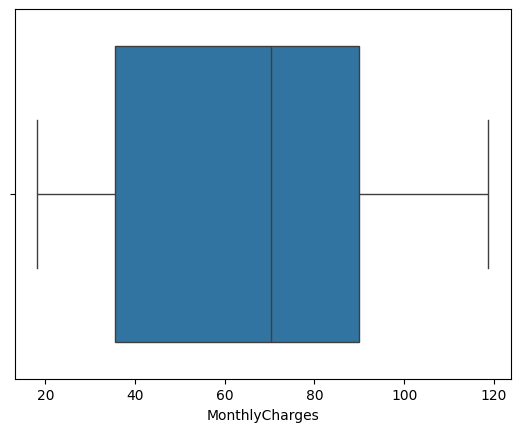

In [11]:
# First, always VISUALIZE before removing anything
sns.boxplot(x=churn['MonthlyCharges'])
plt.show()

In [12]:
# Returns the count of unique values for all columns
unique_counts = churn.nunique()

print(unique_counts)

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [13]:
#checking the unique values in object columns
for col in churn.select_dtypes(include='object').columns:
    print(f"{col}: {churn[col].unique()}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn: ['No' 'Yes']


In [14]:
print(list(churn['TotalCharges'].unique()))

['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8', '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25', '528.35', '1862.9', '39.65', '202.25', '20.15', '3505.1', '2970.3', '1530.6', '4749.15', '30.2', '6369.45', '1093.1', '6766.95', '181.65', '1874.45', '20.2', '45.25', '7251.7', '316.9', '3548.3', '3549.25', '1105.4', '475.7', '4872.35', '418.25', '4861.45', '981.45', '3906.7', '97', '144.15', '4217.8', '4254.1', '3838.75', '1426.4', '1752.65', '633.3', '4456.35', '1752.55', '6311.2', '7076.35', '894.3', '7853.7', '4707.1', '5450.7', '2962', '957.1', '857.25', '244.1', '3650.35', '2497.2', '930.9', '887.35', '49.05', '1090.65', '7099', '1424.6', '177.4', '6139.5', '2688.85', '482.25', '2111.3', '1216.6', '79.35', '565.35', '496.9', '4327.5', '973.35', '918.75', '2215.45', '1057', '927.1', '1009.25', '2570.2', '74.7', '5714.25', '7107', '7459.05', '927.35', '4748.7', '113.85', '1107.2', '2514.5', '19.45', '

In [15]:
#Drop the customerID column because it have 7043 object unique values 
churn = churn.drop(['customerID'],axis=1)

In [16]:
# Convert the column to float
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce')

In [17]:
churn.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
churn['TotalCharges'] = churn['TotalCharges'].fillna(0)

In [19]:
churn.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [20]:
#objects with 2 options
# gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn
twooption = {'No': 0, 'Yes': 1, 'Female': 0, 'Male': 1}
to_fix = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
churn[to_fix] = churn[to_fix].replace(twooption).infer_objects(copy=False)

C:\Users\ammar\AppData\Local\Temp\ipykernel_21628\3565357000.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  churn[to_fix] = churn[to_fix].replace(twooption).infer_objects(copy=False)


In [21]:
churn.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [22]:
#Columns with No/Yes + a 3rd value like "No internet service"
#Example: OnlineSecurity = ['Yes', 'No', 'No internet service']
#Treat 'No internet service' same as 'No'.They both mean the customer doesn't have it.
threeoption = {'No':0, 'Yes':1, 'No internet service':0, 'No phone service':0}
cols_with_no_service = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
churn[cols_with_no_service] = churn[cols_with_no_service].replace(threeoption).infer_objects(copy=False)

C:\Users\ammar\AppData\Local\Temp\ipykernel_21628\795246310.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  churn[cols_with_no_service] = churn[cols_with_no_service].replace(threeoption).infer_objects(copy=False)


In [23]:
churn.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [24]:
#Giving the ml models a new column as 0 and 1 for the the clients that have the contract from month_to_month because they are more likely to churn compared to the clients who have the 1 year or 2 year contracts with the company.
churn['is_month_to_month'] = (churn['Contract'] == 'Month-to-month').astype(int)

In [25]:
churn.dtypes

gender                 int64
SeniorCitizen          int64
Partner                int64
Dependents             int64
tenure                 int64
PhoneService           int64
MultipleLines          int64
InternetService       object
OnlineSecurity         int64
OnlineBackup           int64
DeviceProtection       int64
TechSupport            int64
StreamingTV            int64
StreamingMovies        int64
Contract              object
PaperlessBilling       int64
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
is_month_to_month      int64
dtype: object

In [26]:
#Making a new column of how much the client spends monthly.Why + 1 in the denominator? If tenure = 0 (brand new customer), you'd be dividing by zero which crashes your code. Adding 1 prevents that.
churn['avg_monthly_spend'] = churn['TotalCharges'] / (churn['tenure'] + 1)

In [27]:
#Making a new column of total_services used by a client.If a client has PhoneService=1, OnlineSecurity=1, StreamingTV=1 and the rest=0, their total_services = 3.
#The business logic: A customer using 6 services is deeply embedded in the ecosystem. Cancelling means losing all 6 things at once,they're unlikely to leave. A customer with 1 service can rather leave easily.
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

churn['total_services'] = churn[service_cols].sum(axis=1)

In [28]:
# 1. See the raw count
print(churn['Churn'].value_counts())

# 2. See the percentage (very important for business context)
print(churn['Churn'].value_counts(normalize=True))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


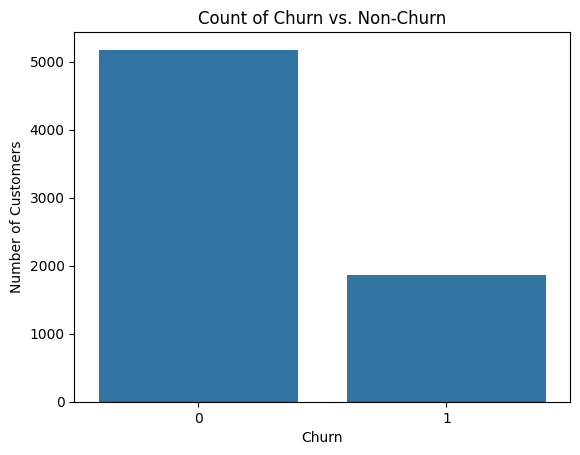

In [29]:
import seaborn as sns

# Quick bar plot
sns.barplot(x=churn['Churn'].value_counts().index, y=churn['Churn'].value_counts().values)
plt.title('Count of Churn vs. Non-Churn')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#Define x and y
x = churn.drop('Churn',axis=1)
y = churn['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,
                                                    random_state=42, 
                                                    stratify=y  # This ensures both sets have 26.5% churn
)


#changing the objects into float values using one hot encoder
features_cat = ['InternetService','Contract','PaymentMethod']
changed = ColumnTransformer([('worker_name',OneHotEncoder(),features_cat)],
                            remainder = 'passthrough')

x_train = changed.fit_transform(x_train)  # fit + transform on train
x_test = changed.transform(x_test)        # only transform on test, no fitting
pd.DataFrame(x_test)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,114.05,8468.20,0.0,116.002740,7.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,100.15,908.55,1.0,100.950000,4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,78.35,3211.20,0.0,76.457143,5.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,78.20,1468.75,1.0,77.302632,3.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,82.65,5919.35,0.0,81.086986,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,87.20,4345.00,0.0,86.900000,7.0
1405,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,20.30,487.95,0.0,16.825862,1.0
1406,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,20.65,93.55,1.0,15.591667,1.0
1407,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,19.70,1051.90,0.0,18.454386,1.0


In [32]:
from sklearn.ensemble import RandomForestClassifier

#fit the model with RandomForestclassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
print('train score=',rfc.score(x_train, y_train))

train score= 0.9980475683351083


In [34]:
print('test score=',rfc.score(x_test,y_test))

test score= 0.7828246983676366


In [35]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Run the 5-fold cross-validation
results = cross_validate(rfc, x_train, y_train, cv=5, scoring=scoring)

#Let's take a look at the average scores
print(f"Average Recall: {results['test_recall'].mean():.2f}")
print(f"Average F1-Score: {results['test_f1'].mean():.2f}")
print(f"Average ROC-AUC: {results['test_roc_auc'].mean():.2f}")

Average Recall: 0.49
Average F1-Score: 0.55
Average ROC-AUC: 0.83


In [36]:
from sklearn.metrics import classification_report

# 1. Get the model's predictions first
y_pred = rfc.predict(x_test)

# 2. Compare the real answers to the predictions
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [37]:
rfc1 = RandomForestClassifier(class_weight='balanced', random_state=42)
rfc1.fit(x_train, y_train)

y_pred = rfc1.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



class_weight=balanced reduced the recall of the model instead of increasing it

In [38]:
#RandomizedSearchCV with f1
from sklearn.model_selection import RandomizedSearchCV

rfc2 = RandomForestClassifier(random_state=42)
# Define a wide range of options
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, None],
    'max_features':['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':[1, 2, 4, 10],
    'bootstrap': [True, False]
}

# n_iter=10 means it will only try 10 random combinations
rscv = RandomizedSearchCV(rfc2, param_distributions=param_dist, n_iter=30, cv=5, scoring='f1', random_state=42)
rscv.fit(x_train, y_train)

print(f"Best Score: {rscv.best_score_}")
print(f"Best Params: {rscv.best_params_}")

Best Score: 0.5708061508309314
Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'bootstrap': True}


In [39]:
#Running the rscv again with scoring=recall
rfc3 = RandomForestClassifier(random_state=42)
rscv = RandomizedSearchCV(rfc3, param_distributions=param_dist, n_iter=30, cv=5, scoring='recall', random_state=42)
rscv.fit(x_train, y_train)

print(f"Best Score: {rscv.best_score_}")
print(f"Best Params: {rscv.best_params_}")

Best Score: 0.5177257525083612
Best Params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}


In [40]:
# Build model with F1-optimized params
rfc_f1 = RandomForestClassifier(n_estimators=300, min_samples_split=5, 
                                 min_samples_leaf=4, max_features=None, 
                                 max_depth=10, bootstrap=True, random_state=42)
rfc_f1.fit(x_train, y_train)
y_pred_f1 = rfc_f1.predict(x_test)

print("F1-Optimized Model:")
print(classification_report(y_test, y_pred_f1))

F1-Optimized Model:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [41]:
# Build model with Recall-optimized params
rfc_recall = RandomForestClassifier(n_estimators=400, min_samples_split=2, 
                                     min_samples_leaf=2, max_features='sqrt', 
                                     max_depth=15, bootstrap=False, random_state=42)
rfc_recall.fit(x_train, y_train)
y_pred_recall = rfc_recall.predict(x_test)

print("Recall-Optimized Model:")
print(classification_report(y_test, y_pred_recall))

Recall-Optimized Model:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.52      0.56       374

    accuracy                           0.79      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [42]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get predicted probabilities for churn class
y_prob = rfc_f1.predict_proba(x_test)[:, 1]

# Get precision, recall and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold where F1 is maximized
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold:.3f}")

# Apply the new threshold
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("\nAfter Threshold Tuning:")
print(classification_report(y_test, y_pred_tuned))

Best Threshold: 0.323

After Threshold Tuning:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.55      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [43]:
import joblib

joblib.dump(rfc_f1, 'churn_model.pkl')
joblib.dump(changed, 'encoder.pkl')  # save the encoder too

['encoder.pkl']

# Conclusion

## Final Model: Random Forest Classifier (F1-Optimized)

| Metric | Before Tuning | After Threshold Tuning |
|--------|--------------|----------------------|
| Recall (Churn) | 0.52 | 0.76 |
| Precision (Churn) | 0.63 | 0.55 |
| F1 (Churn) | 0.57 | 0.63 |
| ROC-AUC | 0.83 | - |

## Key Threshold
Default threshold of 0.5 was replaced with **0.323**, meaning the model flags a customer as a churner when predicted probability exceeds 32.3%.

## What I learned
- Accuracy is a misleading metric for imbalanced classification problems
- Fixing data leakage in preprocessing is critical and easy to get wrong
- Hyperparameter tuning alone gave marginal gains, but threshold tuning jumped recall from 0.52 to 0.76
- For churn problems, recall matters more than precision because missing a real churner is more costly than a false alarm